# Projet - Deep Learning

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

import seaborn as sns
import ipywidgets as widgets

## Contexte

Le diabète fait partie des maladies chroniques les plus courantes aux États-Unis et touche chaque année des millions de personnes. Cette affection sérieuse se traduit par une mauvaise régulation du sucre dans le sang, ce qui peut, à long terme, réduire la qualité de vie et même l’espérance de vie. Au moment de la digestion, les aliments se transforment en sucres qui passent dans le sang. Cela incite le pancréas à produire de l’insuline, une hormone qui permet aux cellules d’utiliser ces sucres comme source d’énergie. Dans le cas du diabète, soit l’organisme ne produit pas assez d’insuline, soit il réagit mal.

L’excès prolongé de sucre dans le sang augmente les risques de complications graves : maladies cardiovasculaires, perte de la vue, amputations ou encore insuffisance rénale. Même si le diabète ne se guérit pas, il est possible d’en limiter les effets grâce à la perte de poids, à une alimentation adaptée, à une activité physique régulière et à un suivi médical approprié. Plus le diagnostic est posé tôt, plus il est possible d’agir efficacement. C’est pour cette raison que les outils de prédiction du risque de diabète représentent un enjeu important de santé publique.

L’ampleur du phénomène est frappante. Selon les Centres pour le contrôle et la prévention des maladies (CDC) en 2018, 34,2 millions d’Américains vivaient avec un diabète, et 88 millions étaient prédiabétiques. Une personne diabétique sur cinq n’en avait pas conscience, et la grande majorité des personnes prédiabétiques ignorait également leur situation. Le diabète de type 2, la forme la plus fréquente, est influencé par de nombreux facteurs : âge, niveau d’études, revenus, zone géographique, origine ethnique ou encore conditions sociales de vie. Les populations les plus défavorisées sont souvent les plus touchées.

La maladie représente aussi un poids financier immense : le coût du diabète diagnostiqué est estimé à environ 327 milliards de dollars par an, et si l’on inclut le diabète non diagnostiqué et le prédiabète, on approche les 400 milliards de dollars.

**Objectifs :**

Nous sommes chargés de construire un modèle de classification binaire permettant de prédire la probabilité qu’une personne soit diabétique à partir des données médicales issues de l’enquête diabetes_binary_health_indicators_BRFSS201 (BRFSS 2015).

Notre objectif ultime est de maximiser la métrique ROC AUC sur un jeu de test non étiqueté.
En parallèle, nous adopterons une approche MLOps (versioning des données, traçabilité et automatisation des traitements) et nous travaillerons en mode Scrum, selon trois sprints, livrables à chaque itération.

## Présentation du jeu de données

Le Système de surveillance des facteurs de risque comportementaux (BRFSS) est une enquête téléphonique annuelle menée par les Centres pour le contrôle et la prévention des maladies (CDC) sur la santé. Chaque année, cette enquête recueille les réponses de plus de 400 000 Américains sur leurs comportements à risque pour la santé, leurs maladies chroniques et leur recours aux services de prévention. Elle est réalisée chaque année depuis 1984. Pour ce projet, nous avons utilisé un fichier CSV des données disponibles sur [Kaggle](https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset) pour l'année 2015. Ce jeu de données contient les réponses de 253 680 personnes et comporte 22 variables. Ces variables correspondent soit à des questions posées directement aux participants, soit à des variables calculées à partir de leurs réponses individuelles.

Les variables du dataset sont :
- **Diabetes_binary :** Objectif de l’étude : indique si la personne est diabétique (1 = Oui, 0 = Non).

- **HighBP :** Indique si le sujet souffre d’hypertension artérielle. 
- **HighChol :** Le sujet a un taux de cholestérol élevé. 
- **CholCheck :** Le sujet a effectué un contrôle du cholestérol dans les 5 dernières années. 
- **BMI :** Indice de masse corporelle. 
- **Smoker :** Le sujet a fumé plus de 100 cigarettes au cours de sa vie. 
- **Stroke :** Le sujet a déjà eu un AVC. 
- **HeartDiseaseorAttack :** Le sujet a déjà eu une maladie coronarienne ou un infarctus du myocarde. 
- **PhysActivity :** Le sujet a pratiqué une activité physique au cours des 30 derniers jours (hors travail). 
- **Fruits :** Le sujet consomme des fruits au moins une fois par jour. 
- **Veggies :** Le sujet consomme des légumes au moins une fois par jour. 
- **HvyAlcoholConsump :** Forte consommation d’alcool (hommes ≥ 14 verres/semaine, femmes ≥ 7). 
- **AnyHealthcare :** Le sujet bénéficie d’une couverture santé (assurance ou mutuelle). 
- **NoDocbcCost :** Le sujet n’a pas consulté un médecin dans les 12 derniers mois à cause du coût. 
- **GenHlth :** État de santé général (1 = excellent, 2 = très bon, 3 = bon, 4 = moyen, 5 = mauvais). 
- **MentHlth :** Nombre de jours de mauvaise santé mentale sur les 30 derniers jours. 
- **PhysHlth :** Nombre de jours de maladie ou blessure sur les 30 derniers jours. 
- **DiffWalk :** Difficulté à marcher ou monter des escaliers. 
- **Sex :** Sexe du sujet (0 = Femme, 1 = Homme). 
- **Age :** Tranche d’âge (1 = 18–24, …, 13 = 80+). 
- **Education :** Niveau d’éducation (1 = jamais scolarisé, …). 
- **Income :** Niveau de revenu (1 < 10k$, …, 8 < 75k$).


### Séparation des données

Il est primordial de séparer les données en deux catégories bien distinctes :
- Variable cible : elle représente le résultat que l’on cherche à prédire ou à expliquer à l’aide du modèle.

- Variables explicatives : elles correspondent aux variables utilisées pour prédire, expliquer ou décrire la variable cible.

Dans ce contexte, la seule variable cible, c'est-à-dire celle que nous allons devoir prédire dans notre projet sera **Diabetes_binary**.

Tout le reste des variables sont des variables explicatives. 

On distingue principalement deux types de variables : les variables quantitatives et les variables qualitatives. Cette distinction est essentielle pour choisir les méthodes d’analyse et de modélisation adaptées.

Une variable quantitative (ou numérique) correspond à une information mesurable qui s’exprime par un nombre (ex: Age, poids, température, supercifie, ...). Dans notre contexte les variables sont considérés comme quantitative continue (variable qui prend un infini de valeurs réelles à l'intérieur d'un interval donné) :
- BMI
- MenHlth
- PhysHlth

Une variable qualitative (ou catégorielle) décrit une caractéristique non numérique. Elle représente des catégories ou des états. Il y a 2 types de variables qualitatives : qualitative nominale (étiquetage, binaire) et qualitative ordinale (données définies dans une relation d'ordre entre différentes catégories possibles). Variables qualitatives nominales :
- Diabetes_binary
- HighBP
- HighChol
- CholCheck
- Smoker
- Stroke
- HeartDiseaseorAttack 
- PhysActivity 
- Fruits
- Veggies 
- HvyAlcoholConsump 
- AnyHealthcare
- NoDocbcCost
- DiffWalk
- Sex 

Variables ordinales :
- GenHlth
- Age
- Income
- Education

### Variables sensibles 

À des fins d’anonymisation et de limitation des biais, nous avons choisi de retirer certaines variables non essentielles à la prédiction du diabète.
- **Income :** le niveau de revenu peut être indirectement lié au diabète (accès aux soins, alimentation), mais nous choisissons de l’exclure afin d’éviter d’introduire des biais socio-économiques dans le modèle.
- **Education :** de même, le niveau d’éducation peut influencer certains comportements de santé, mais il n’est pas un facteur médical direct. Nous le retirons afin de limiter les biais et de conserver un modèle centré sur des variables de santé.

Le dataset contient également certaines variables pouvant être considérées comme subjectives. En effet, ces variables reposent sur des auto-évaluations des individus, ce qui peut introduire des biais liés à la perception personnelle ou à l’état mental.
- **GenHlth**
- **MenHlth**
- **PhysHlth**

### Scission des données (Train/Test/Validation)

Afin d'entrainer au mieux notre modèle avec nos donnéees, nous procédons à une séparation du dataset en 3 sous-dataset.

- **Dataset d'entrainement :** Ce jeu de données est utilisé pour entraîner le modèle. Il permet au modèle d’apprendre les relations et les patterns présents dans les données.
- **Dataset de validation :** Ce jeu de données est utilisé pendant l’entraînement pour évaluer les performances du modèle de manière intermédiaire. Il permet d’ajuster les hyperparamètres et de choisir le meilleur modèle, tout en limitant le surapprentissage (overfitting).
- **Dataset de test :** Ce jeu de données est utilisé uniquement à la fin du processus. Il permet d’évaluer les performances finales du modèle sur des données qu’il n’a jamais vues. On compare alors les valeurs prédites aux valeurs réelles afin d’obtenir une estimation fiable de sa capacité de généralisation.

Afin d'assurer une répartition équilibrée des données, nous allons utiliser un découpage de 70% des données dans le dataset d'entrainement, 15% de validation et 15% de donnéees de test. 

## Pré-traitement des données

### Chargement du dataset

In [94]:
path = "Health_Data/diabetes_binary_health_indicators_BRFSS2015.csv"

In [95]:
def load_dataset(path):
    dataset = pd.read_csv(path)
    return dataset

Suppression des variables sensibles :

In [96]:
def remove_sensible_data(df, columns_to_remove):
    df = df.copy()
    df = df.drop(columns=columns_to_remove)
    return df

### Gestion des valeurs manquantes

Les valeurs manquantes sont un problème courant dans les ensembles de données réels et peuvent nuire aux performances des modèles de Machine Learning. Il existe plusieurs méthodes pour gérer les valeurs manquantes dans un dataset :
- **Suppression de la ligne :** supprimer les observations contenant des valeurs manquantes peut être pertinent, mais si ces valeurs sont nombreuses, cela peut entraîner une perte importante d’information.
- **Remplir avec la médiane :** méthode robuste, particulièrement adaptée aux variables numériques contenant des valeurs extrêmes (outliers).
- **Remplir avec la moyenne :** adaptée aux variables numériques sans forte présence d’outliers.
- **Remplir avec la valeur suivante (forward fill):** consiste à remplacer la valeur manquante par la valeur suivante dans la série.
- **Remplir avec la valeur précédente (backward fill):** consiste à remplacer la valeur manquante par la valeur précédente.
- **Remplir avec le mode :** remplace la valeur manquante par la valeur la plus fréquente, généralement utilisée pour les variables catégorielles.

Pour toutes nos valeurs, nous avons choisi de remplir les valeurs manquantes par le "mode", c'est à dire la valeur la plus fréquente car toutes nos valeurs sont catégorielles.

In [97]:
def check_missing_values(df):
    missing_values_columns = []
    for i in range(len(df.columns)):
        if df.iloc[:, i].isnull().sum() > 0:
            missing_values_columns.append(df.columns[i])
            print(f"Column {df.columns[i]} has {df.iloc[:, i].isnull().sum()} missing values.")
    
    if not missing_values_columns:
        print("No missing values found in the dataset.")
    return missing_values_columns

def fill_missing_columns(df, missing_columns):
    # Fill with mode
    df[missing_columns] = df[missing_columns].fillna(df[missing_columns].mode().iloc[0])
    print(f"Column {missing_columns} filled with value: {df[missing_columns].mode().iloc[0]}")

    return df

### Gestion des valeurs aberrantes

La gestion des valeurs aberrantes est primordiale pour l'entrainement d'un modèle, des valeurs aberrantes peuvent fortement influencer negativement l'entrainement du modèle en le poussant à apprendre des relations fausses. Pour cela, il existe plusieurs méthodes :
- **Z-score :** On observe de combien d’écarts types la valeur est éloigné de sa moyenne. Si le résultat est > 3 écarts types, la valeur est considérée comme outlier.
- **IQR (Interquartile Range) :** On utilise les quartiles. Toute valeur au-delà de *Q3 + 1.5 * IQR* est considérée comme suspecte.

Après la suppression des données sensibles, il ne reste qu'une variable quantitative qui est BMI. La méthode Z-score est utilisé pour des valeurs avec une distribution normale. Comme nous allons le voir dans la partie suivante, la variable BMI ne suit pas une distribution normale donc nous utiliserons la méthode IQR pour cette donnée. Nous supprimons les lignes doublons.

In [98]:
def outliers_detection(df):

    df = df.copy()

    iqr = df['BMI'].quantile(0.75) - df['BMI'].quantile(0.25)
    lower_bound = df['BMI'].quantile(0.25) - 1.5 * iqr
    upper_bound = df['BMI'].quantile(0.75) + 1.5 * iqr

    outlier_number = (df['BMI'] < lower_bound).sum() + (df['BMI'] > upper_bound).sum()

    df = df[(df['BMI'] >= lower_bound) & (df['BMI'] <= upper_bound)]
    print(f"Outliers removed! Lower bound: {lower_bound}, Upper bound: {upper_bound}, Number of outliers removed: {outlier_number}")    
    return df

### Normalisation des données

La normalisation (ou feature scaling) est l'étape qui permet de mettre toutes tes variables sur la même échelle. Sans cela, un réseau de neurones donnera 1000 fois plus d'importance à une variable "Salaire" (ex: 50 000) qu'à une variable "Âge" (ex: 30), simplement parce que le chiffre est plus grand.
Les méthodes de normalisations selon les cas d’usages :
- **Min-Max-Scaling :** C'est la méthode qui écrase les données dans un intervalle fixe, généralement [0, 1]. Très utile quand les valeurs ont des bornes connues et censés ne pas être dépasser. 
- **Standardisation :** Transformation des données pour qu'elles aient une moyenne de 0 et un écart-type de 1. C'est la méthode par défaut pour la plupart des algorithmes de Machine Learning et de Deep Learning.

In [99]:
def normalize_data(df, columns):
    df = df.copy()
    scaler = MinMaxScaler()
    
    df[columns] = scaler.fit_transform(df[columns])
    
    return df, scaler

Nous utiliserons la méthode de normalisation Min-Max-Scaling pour la variable BMI, car elle a des bornes connues (généralement entre 10 et 50) et nous voulons que toutes les valeurs soient comprises entre 0 et 1 pour faciliter l'apprentissage du modèle.

### Gestion des doublons

Les doublons peuvent influencer négativement l'entraînement du modèle en introduisant un biais dans les données. En effet, si une même observation est présente plusieurs fois, le modèle peut lui accorder une importance disproportionnée, ce qui peut fausser les résultats et réduire la capacité de généralisation du modèle. Par conséquent, il est essentiel de détecter et de supprimer les doublons pour garantir que le modèle apprend à partir d'un ensemble de données représentatif et équilibré. Sachant que notre dans notre dataset, nous n’avons aucune variable qui pourrait être considéré comme un "identifiant unique" (comme un ID, numéro de téléphone, ...), nous allons considérer un doublons comme exactement la même ligne de données qui sera présente 2 fois ou plus dans notre dataset.

In [100]:
def manage_doublons(df):
    df = df.copy()

    nb_duplicates = df.duplicated().sum()

    df = df.drop_duplicates(keep='first')
    print(f"Doublons removed! Number of doublons removed: {nb_duplicates}")
    return df

### Chargement des données

In [101]:
df_data = load_dataset(path)

df_data = remove_sensible_data(df_data, ['GenHlth', 'MentHlth', 'PhysHlth', 'Income', 'Education'])

quantitative_columns = ['BMI', 'Age']

### Analyse exploratoire quantitative

Cette section présente une analyse statistique du jeu de données afin de mieux comprendre 
la distribution des variables, leurs relations et la présence éventuelle de déséquilibres.

In [102]:
# Résumé statistique enrichi
print("=== Statistiques descriptives ===")
display(df_data.describe().T.style.background_gradient(cmap='Blues'))

# Distribution de la variable cible
print("\n=== Distribution de Diabetes_binary ===")
target_counts = df_data['Diabetes_binary'].value_counts()
target_pct    = df_data['Diabetes_binary'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': target_counts, 'Pourcentage (%)': target_pct.round(2)}))

=== Statistiques descriptives ===


,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.000000,0.139333,0.346294,0.000000,0.000000,0.000000,0.000000,1.000000
HighBP,253680.000000,0.429001,0.494934,0.000000,0.000000,0.000000,1.000000,1.000000
HighChol,253680.000000,0.424121,0.494210,0.000000,0.000000,0.000000,1.000000,1.000000
CholCheck,253680.000000,0.962670,0.189571,0.000000,1.000000,1.000000,1.000000,1.000000
BMI,253680.000000,28.382364,6.608694,12.000000,24.000000,27.000000,31.000000,98.000000
Smoker,253680.000000,0.443169,0.496761,0.000000,0.000000,0.000000,1.000000,1.000000
Stroke,253680.000000,0.040571,0.197294,0.000000,0.000000,0.000000,0.000000,1.000000
HeartDiseaseorAttack,253680.000000,0.094186,0.292087,0.000000,0.000000,0.000000,0.000000,1.000000
PhysActivity,253680.000000,0.756544,0.429169,0.000000,1.000000,1.000000,1.000000,1.000000
Fruits,253680.000000,0.634256,0.481639,0.000000,0.000000,1.000000,1.000000,1.000000



=== Distribution de Diabetes_binary ===
                  Count  Pourcentage (%)
Diabetes_binary                         
0.0              218334            86.07
1.0               35346            13.93


Le dataset est **déséquilibré** : la classe 0 (non-diabétique) représente environ 86% des observations contre 14% pour la classe 1. Ce déséquilibre devra être pris en compte lors de l'entraînement du modèle (ex : class_weight, SMOTE, etc.). Nous pouvons également observer les valeurs non normalisées de la variable BMI, qui est la seule variable quantitative du dataset restante et qui devra être normalisée avant l'entrainement du modèle. Nous comparerons la version brute à la version normalisée de cette variable dans la section suivante.

Une matrice de corrélation permet d'avoir une vue d'ensemble de la corrélation entre les variables explicatives et la variable cible. Nous allons afficher une Heatmap de la corrélation de Spearman (corrélation adapté pour les variables ordinales) afin de nous permettre d'avoir une représentation graphique.

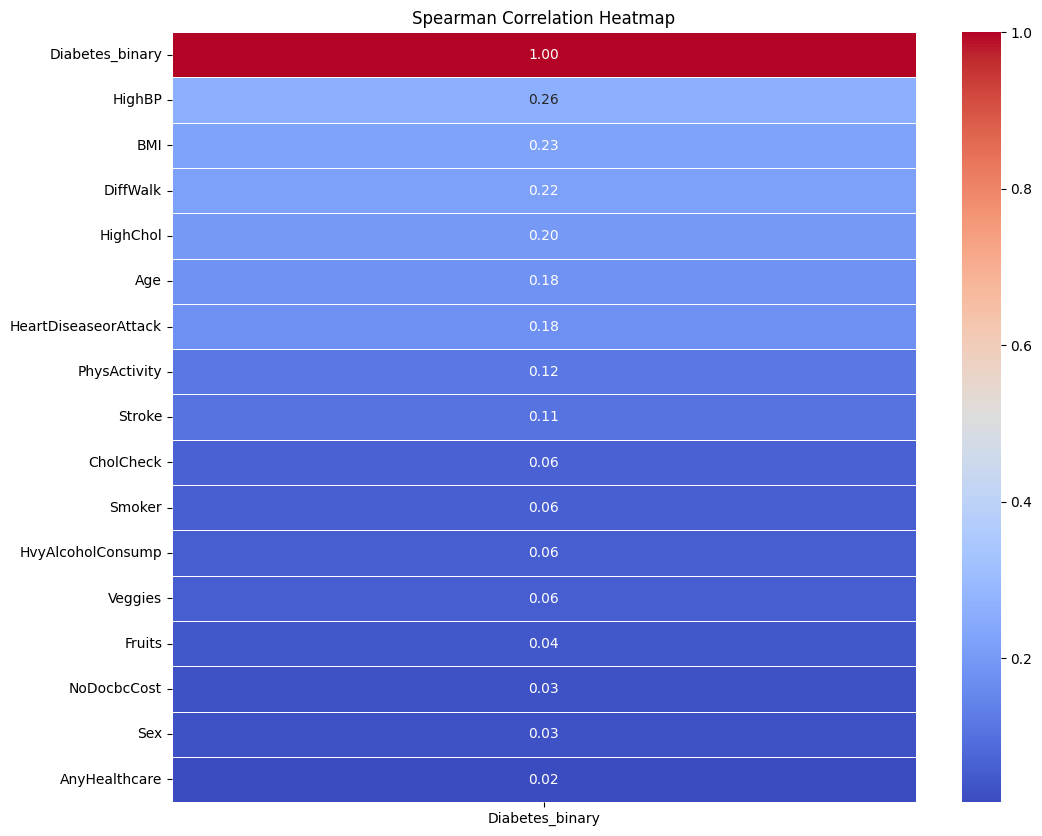

In [103]:
corr_pearso = df_data.corr(method='spearman')[['Diabetes_binary']].abs().sort_values(by='Diabetes_binary', ascending=False)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_pearso, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Spearman Correlation Heatmap")
plt.show()

### Analyse exploratoire qualitative (EDA visuelle)


L'objectif est ici de visualiser graphiquement les distributions et les relations entre variables afin de dégager des tendances interprétables. Nous allons nous concentrer uniquement sur l'unique variable quantitative (BMI) car les autres variables sont catégorielles.

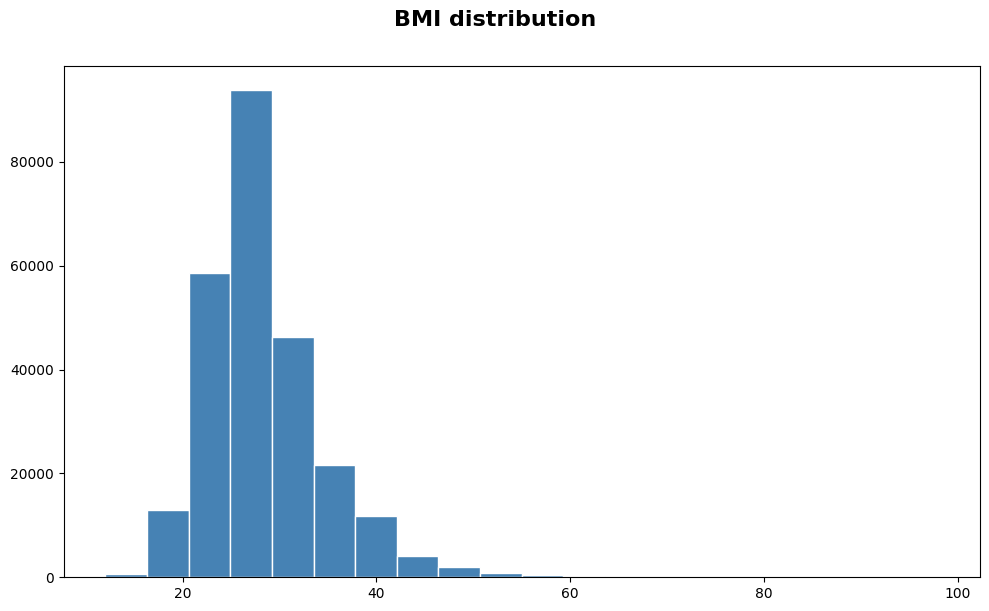

In [104]:
# Distribution de la variable BMI
df_data['BMI'].hist(figsize=(10, 6), bins=20, color='steelblue', edgecolor='white', grid=False)
plt.suptitle("BMI distribution", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Nous pouvons voir que la distribution de la variable BMI n'est pas normale, elle est plutôt asymétrique. Cela nous permettra de nous orienter vers des méthodes de pré-traitement adapté à ce type de distribution.

Les graphiques de boite à moustache (boxplot) permettent de visualiser la distribution d'une variable quantitative (BMI) en fonction d'une variable catégorielle (Diabetes_binary). Ils montrent la médiane, les quartiles et les valeurs extrêmes.

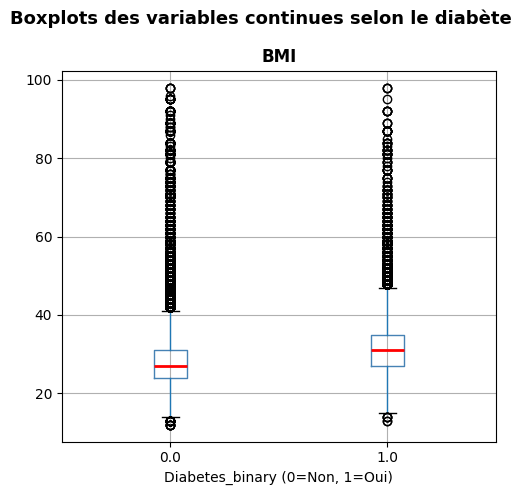

In [105]:
# Boxplots des variables continues selon Diabetes_binary
continuous_cols = ['BMI']

fig, axes = plt.subplots(1, len(continuous_cols), figsize=(5 * len(continuous_cols), 5))
if len(continuous_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, continuous_cols):
    df_data.boxplot(column=col, by='Diabetes_binary', ax=ax,
                    boxprops=dict(color='steelblue'),
                    medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel("Diabetes_binary (0=Non, 1=Oui)")

plt.suptitle("Boxplots des variables continues selon le diabète", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

La variable BMI contient un grand nombre de valeurs extrêmes (outliers) qui peuvent potentiellement influencer négativement l'entraînement du modèle.  Nous savons désormais qu'il nous faut gérer impérativement ces valeurs aberrantes avant d'entraîner notre modèle.

In [106]:
def save_dataset(train, val, test, path):
    train.to_csv(f"{path}train_dataset.csv", index=False)
    val.to_csv(f"{path}val_dataset.csv", index=False)
    test.to_csv(f"{path}test_dataset.csv", index=False)
    print("Dataset saved to:", path)

In [107]:
def split_dataset(df):
    train, temp = train_test_split(df, test_size=0.3, random_state=42)
    val, test = train_test_split(temp, test_size=0.5, random_state=42)

    df_0 = train[train['Diabetes_binary'] == 0]
    df_1 = train[train['Diabetes_binary'] == 1]

    min_size = min(len(df_0), len(df_1))

    df_0_balanced = df_0.sample(min_size, random_state=42)
    df_1_balanced = df_1.sample(min_size, random_state=42)

    train_balanced = pd.concat([df_0_balanced, df_1_balanced])

    return train_balanced, val, test

### Traitement (main)

In [108]:
# Gestion des doublons
df_data = manage_doublons(df_data)

# Vérification des valeurs manquantes
columns_missing = check_missing_values(df_data)
if columns_missing:
    df_data = fill_missing_columns(df_data, columns_missing)

# Détection des outliers
df_data = outliers_detection(df_data)

# Normalisation
df_data, scaler = normalize_data(df_data, quantitative_columns)

# Split du dataset
train, val, test = split_dataset(df_data)

# Save du dataset nettoyé
# save_dataset(train, val, test, "Health_Data/")

Doublons removed! Number of doublons removed: 148287
No missing values found in the dataset.
Outliers removed! Lower bound: 11.5, Upper bound: 47.5, Number of outliers removed: 3300


Maintenant que nous avons effectué un traitement complet de nos données, nous allons analyser les données après le traitement afin de vérifier que les différentes étapes ont été correctement appliquées et que les données sont prêtes pour l'entraînement du modèle.

In [109]:
# Résumé statistique post-traitement
print("=== Statistiques descriptives ===")
display(df_data.describe().T.style.background_gradient(cmap='Blues'))

=== Statistiques descriptives ===


,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,102093.000000,0.240310,0.427274,0.000000,0.000000,0.000000,0.000000,1.000000
HighBP,102093.000000,0.530742,0.499057,0.000000,0.000000,1.000000,1.000000,1.000000
HighChol,102093.000000,0.492130,0.499941,0.000000,0.000000,0.000000,1.000000,1.000000
CholCheck,102093.000000,0.931180,0.253148,0.000000,1.000000,1.000000,1.000000,1.000000
BMI,102093.000000,0.499780,0.185744,0.000000,0.371429,0.485714,0.628571,1.000000
Smoker,102093.000000,0.529987,0.499102,0.000000,0.000000,1.000000,1.000000,1.000000
Stroke,102093.000000,0.090564,0.286990,0.000000,0.000000,0.000000,0.000000,1.000000
HeartDiseaseorAttack,102093.000000,0.174782,0.379782,0.000000,0.000000,0.000000,0.000000,1.000000
PhysActivity,102093.000000,0.611462,0.487420,0.000000,0.000000,1.000000,1.000000,1.000000
Fruits,102093.000000,0.533474,0.498881,0.000000,0.000000,1.000000,1.000000,1.000000


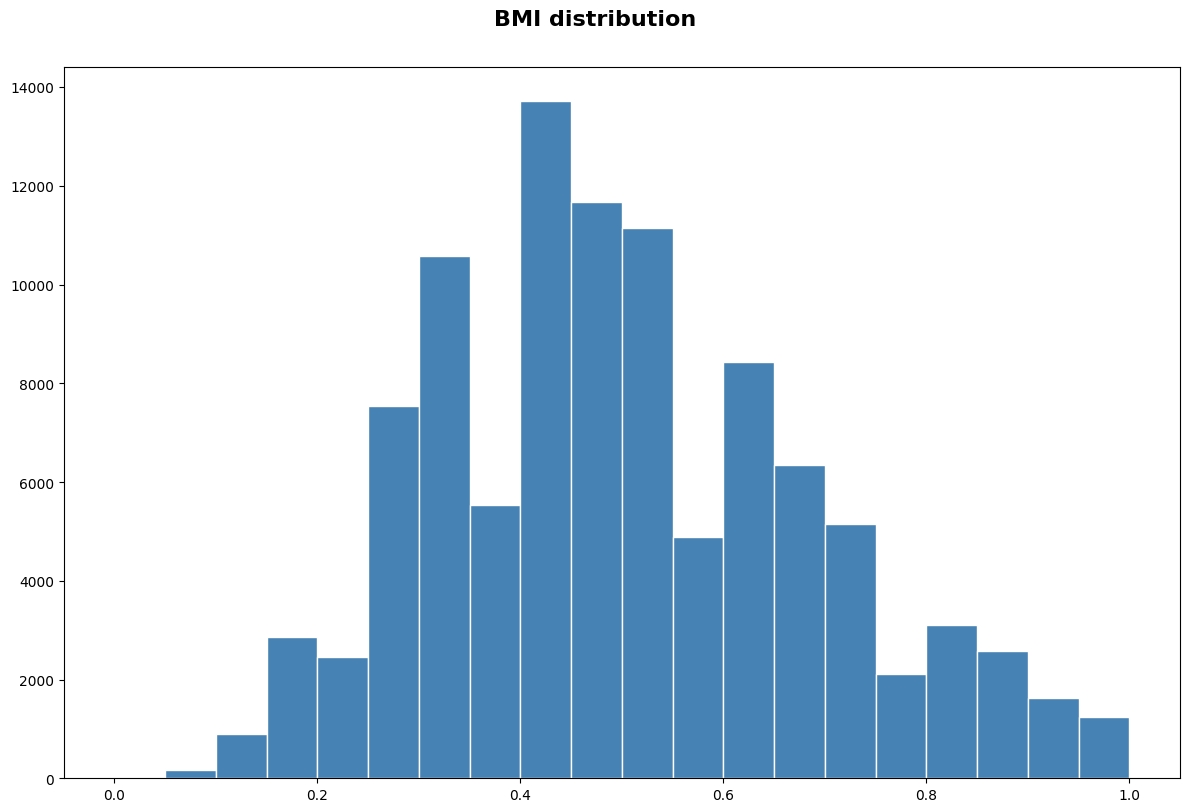

In [110]:
# Distribution de la variable BMI après traitement
df_data['BMI'].hist(figsize=(12, 8), bins=20, color='steelblue', edgecolor='white', grid=False)
plt.suptitle("BMI distribution", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

La variable BMI à été normalisée entre 0 et 1, ce qui évitera à notre modèle d'être biaisé par l'échelle des données et lui permettra d'apprendre plus efficacement. On voit également qu'il suit une loi normale après le traitement des outliers, ce qui est un bon signe pour l'entraînement du modèle. Nous avons également supprimé les doublons, ce qui garantit que notre modèle n'apprendra pas à partir de données redondantes et biaisées.

In [111]:
temp_df = load_dataset("Health_Data/train_dataset.csv")

print("\n=== Distribution de Diabetes_binary ===")
target_counts = temp_df['Diabetes_binary'].value_counts()
target_pct    = temp_df['Diabetes_binary'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': target_counts, 'Pourcentage (%)': target_pct.round(2)}))


=== Distribution de Diabetes_binary ===
                 Count  Pourcentage (%)
Diabetes_binary                        
0.0              17225             50.0
1.0              17225             50.0


Nous avons vérifié que notre dataset de train est désormais également équilibré.  

## Architecture du modèle

Pour l'architecture de notre modèle, il va nous falloir déterminer plusieurs paramètres de la structure de notre modèle qui seront crutiaux pour son entrainement. Voici les principaux paramètres à définir :
- **Nombre de couches cachées,**
- **Nombre de neurones par couche,**
- **Fonction d'activation,**
- **Fonction de perte,**
- **Hyperparamètres du modèle** (taux d'apprentissage, nombre d'itérations, ...), 
- **Méthodes anti-surapprentissage.**

### Définition du nombre de couches cachées

Une couche cachée dans un réseau de neurones est une couche intermédiaire située entre la couche d'entrée et la couche de sortie. Elle est constituée d'un nombre de neurones qui effectuent des calculs sur les données d'entrée pour extraire des caractéristiques et apprendre des représentations complexes. 
Le nombre de couches cachées influent directement sur le raisonnement du modèle. En effet, plus il y a de couches cachées, plus le modèle peut apprendre des représentations théoriquement complexes, cependant, cela peut aussi entraîner un surapprentissage si le modèle est trop complexe par rapport à la quantité de données disponibles. Il est donc important de trouver l'équilibre entre la complexité du modèle et la quantité de données pour éviter le surapprentissage tout en permettant au modèle d'apprendre les représentations de nos données.

Nous allons faire le tests de différents nombre de couches cachées (entre 2 et 4) afin de trouver quel nombre de couches cachées nous permet d'obtenir les meilleurs résultats.  

### Définition du nombre de neurones par couches

Le nombre de neurones par couche est un paramètre clé dans la conception d'un réseau de neurones. Les neurones correspondent à des unités de calcul (fonctions) qui vont effectuer des calculs sur les données et donc apprendre concrètement les relations. 
Le nombre de neurones influence également la capacité du modèle à apprendre, un nombre faible de neurones peut limiter sa capacité à capturer des relations complexes, tandis qu'un nombre trop élevé peut entrainer un surapprentissage. Encore une fois, il faut trouver le bon équilibre entre le nombre de neurones et la quantité de données.

Le nombre de neurones par couche est généralement de 32, 64 ou 128. Toutes les couches cachées de notre modèle ne sont pas nécessairement composées du même nombre de neurones, nous allons faire le test de différentes combinaisons de nombre de neurones par couches pour optimiser les résultats.

### Définition des fonctions d'activation

In [112]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [113]:
def relu(x):
    return np.maximum(0, x)

def relu_prime(z):
    return (z > 0).astype(float)

### Défintion de la fonction de perte

In [114]:
# def loss_function(y_true, y_predidction):
#     return -np.mean(y_true * np.log(y_predidction) + (1 - y_true) * np.log(1 - y_predidction))

def loss_function(y_true, y_pred, pos_weight=1.0, neg_weight=1.0):
    y_pred = np.clip(y_pred, 1e-15, 1-1e-15)
    weights = y_true * pos_weight + (1 - y_true) * neg_weight
    loss = -np.mean(weights * (y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)))
    return loss    

### Définition des hyperparamètres du modèle

In [115]:
neural_info = {
    "input_size": 16,
    "hidden_params": [
        {"hidden_size": 64, "activation": relu, "activation_prime": relu_prime},
        {"hidden_size": 32, "activation": relu, "activation_prime": relu_prime},
        {"hidden_size": 8, "activation": relu, "activation_prime": relu_prime}
    ],
    "output_params": [
        {"output_size": 1, "activation": sigmoid}
    ]
}

## Métriques d’évaluation

Afin d'évaluer les performances de notre modèle, nous allons utiliser plusieurs métriques d'évaluation adaptées à la classification. Ces métriques vont également nous permettre de comparer lors de la phase de test les différentes versions de notre modèle et ainsi choisir la meilleure version.

### Accuracy (Justesse)

**L'accuracy** (justesse) correpond à la proportion de prédictions correctes quelque soit la classe prédite. C'est une métrique basique qui permet d'évaluer si notre modèle a bien appris à différencier les classes, cependant, dans le cas d'un dataset déséquilibré, l'accuracy peut être trompeuse. En effet, si la classe majoritaire représente 90% des données, un modèle qui prédit systématiquement cette classe aura une accuracy de 90% sans pour autant être performant pour la classe minoritaire.

Formule de l'accuracy :
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

Avec :
- TP (True Positives) : nombre de vrais positifs (prédits positifs et réels positifs)
- TN (True Negatives) : nombre de vrais négatifs (prédits négatifs et réels négatifs)
- FP (False Positives) : nombre de faux positifs (prédits positifs et réels négatifs)
- FN (False Negatives) : nombre de faux négatifs (prédits négatifs et réels positifs)

### Recall (Rappel)

Le **recall** (rappel ou taux de vrais positifs) correspond à la proportion de valeurs positifs qui l'ont réellement été prédit comme positifs. Cette métrique est très important dans notre contexte, car l’objectif est d’identifier toutes les personnes réellement diabétiques. Il est donc essentiel de prédire correctement un patient diabétique plutôt que de le classer à tort comme non diabétique, ce qui correspond à un faux négatif. Dans ce contexte, le faux négatif est l’erreur la plus grave, puisqu’un patient diabétique non détecté risque de ne pas recevoir la prise en charge nécessaire.

Formule du recall :
$$Recall = \frac{TP}{TP + FN}$$

### Précision

La **précision** correspond à la proportion de valeurs prédites comme positives qui sont réellement positives. Dans notre contexte, cette métrique reste importante, mais elle est moins prioritaire que le recall. En effet, la précision mesure la capacité du modèle à limiter les faux positifs, c’est-à-dire les patients classés à tort comme diabétiques alors qu’ils ne le sont pas.

Formule de la précision :
$$Precision = \frac{TP}{TP + FP}$$

### F1 score

Le **F1 score** correpond à la moyenne harmonique entre la précision et le recall. Il équilibre le compromis entre les faux positifs et les faux négatifs, et fournit une mesure plus précise des performances du modèle. Particulièrement important dans notre contexte car le F1 score va servir d'évaluation globale de notre modèle en prenant en compte à la fois la précision et le recall. 

Formule du F1 score :
$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

### Implémentation (code)

In [116]:
def accuracy(y_true, y_pred):
    y_pred_labels = (y_pred >= 0.5).astype(int)
    return np.mean(y_true == y_pred_labels)

def precision(y_true, y_pred):
    y_pred_labels = (y_pred >= 0.5).astype(int)
    tp = np.sum((y_true == 1) & (y_pred_labels == 1))
    fp = np.sum((y_true == 0) & (y_pred_labels == 1))
    return tp / (tp + fp + 1e-15)

def recall(y_true, y_pred):
    y_pred_labels = (y_pred >= 0.5).astype(int)
    tp = np.sum((y_true == 1) & (y_pred_labels == 1))
    fn = np.sum((y_true == 1) & (y_pred_labels == 0))
    return tp / (tp + fn + 1e-15)

def f1_score(y_true, y_pred):
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    return 2 * (p * r) / (p + r + 1e-15)

### Gestion du surapprentissage

## Implémentation du modèle

In [117]:
class MLP:
    def __init__(self, neural_info, alpha=0.01, nb_iters=10000):
        self.neural_info = neural_info
        self.W1 = np.random.randn(neural_info["input_size"], neural_info["hidden_params"][0]["hidden_size"]) * np.sqrt(2 / neural_info["input_size"])
        self.b1 = np.zeros((1, neural_info["hidden_params"][0]["hidden_size"]))
        
        for i in range(1, len(neural_info["hidden_params"])):
            prev_size = neural_info["hidden_params"][i-1]["hidden_size"]
            curr_size = neural_info["hidden_params"][i]["hidden_size"]
            setattr(self, f"W{i+1}", np.random.randn(prev_size, curr_size) * np.sqrt(2 / prev_size))
            setattr(self, f"b{i+1}", np.zeros((1, curr_size)))
        
        last_hidden = neural_info["hidden_params"][-1]["hidden_size"]
        output_size = neural_info["output_params"][0]["output_size"]
        
        self.W_out = np.random.randn(last_hidden, output_size) * np.sqrt(1 / last_hidden)
        self.b_out = np.zeros((1, output_size))

        self.alpha = alpha
        self.nb_iters = nb_iters

    def fit(self, X, Y):
        m = X.shape[0]

        for i in range(self.nb_iters):

            # ╭────────────────────────────────────────────────────────╮
            # │                        forward                         │
            # ╰────────────────────────────────────────────────────────╯

            A = X
            self.As = [X]
            self.Zs = []

            for j, layer in enumerate(self.neural_info["hidden_params"]):
                W = getattr(self, f"W{j+1}")
                b = getattr(self, f"b{j+1}")

                # print(f"Couche {j+1}")
                # print("A:", A.shape)
                # print("W:", W.shape)
                # print("b:", b.shape)

                Z = A @ W + b
                A = layer["activation"](Z)

                self.Zs.append(Z)
                self.As.append(A)

            Z_out = A @ self.W_out + self.b_out
            A_out = self.neural_info["output_params"][0]["activation"](Z_out)

            cost = loss_function(Y, A_out, pos_weight=4, neg_weight=1)
            # cost = loss_function(Y, A_out)

            # ╭────────────────────────────────────────────────────────╮
            # │                      backward                          │
            # ╰────────────────────────────────────────────────────────╯
            grads_W = {}
            grads_b = {}

            # sortie
            delta = A_out - Y

            grads_W["out"] = (self.As[-1].T @ delta) / m
            grads_b["out"] = np.mean(delta, axis=0, keepdims=True)

            # couches cachées
            for k in range(len(self.neural_info["hidden_params"]) - 1, -1, -1):
                Z = self.Zs[k]
                activation_prime = self.neural_info["hidden_params"][k]["activation_prime"]

                if k == len(self.neural_info["hidden_params"]) - 1:
                    delta = (delta @ self.W_out.T) * activation_prime(Z)
                else:
                    delta = (delta @ getattr(self, f"W{k+2}").T) * activation_prime(Z)

                grads_W[k+1] = (self.As[k].T @ delta) / m
                grads_b[k+1] = np.mean(delta, axis=0, keepdims=True)
            
            for k in range(1, len(self.neural_info["hidden_params"]) + 1):
                setattr(self, f"W{k}", getattr(self, f"W{k}") - self.alpha * grads_W[k])
                setattr(self, f"b{k}", getattr(self, f"b{k}") - self.alpha * grads_b[k])

            self.W_out -= self.alpha * grads_W["out"]
            self.b_out -= self.alpha * grads_b["out"]
                
            if i % 100 == 0:
                print(f"Iteration {i}/{self.nb_iters}, Cost: {cost:.4f}")
    
        return self

    def predict(self, X):
        A = X

        for j, layer in enumerate(self.neural_info["hidden_params"]):
            W = getattr(self, f"W{j+1}")
            b = getattr(self, f"b{j+1}")

            Z = A @ W + b
            A = layer["activation"](Z)
        
        Z_out = A @ self.W_out + self.b_out
        A_out = self.neural_info["output_params"][0]["activation"](Z_out)

        return (A_out > 0.4).astype(int)

### Entrainement

In [118]:
path_train = "Health_Data/train_dataset.csv"
path_test = "Health_Data/test_dataset.csv"
path_val = "Health_Data/val_dataset.csv"

df_train = load_dataset(path_train)
df_test = load_dataset(path_test)
df_val = load_dataset(path_val)

df_blabla = load_dataset(path)

In [119]:
X_train, Y_train = df_train.drop(columns=['Diabetes_binary']).values, df_train['Diabetes_binary'].values.reshape(-1, 1)
# X_train, Y_train = df_blabla.drop(columns=['Diabetes_binary']).values, df_blabla['Diabetes_binary'].values.reshape(-1, 1)
X_test , Y_test = df_test.drop(columns=['Diabetes_binary']).values, df_test['Diabetes_binary'].values.reshape(-1, 1)
X_val  , Y_val  = df_val.drop(columns=['Diabetes_binary']).values, df_val['Diabetes_binary'].values.reshape(-1, 1)

In [120]:
model = MLP(neural_info, alpha=0.01, nb_iters=1000)
model.fit(X_train, Y_train)

Iteration 0/1000, Cost: 1.8265
Iteration 100/1000, Cost: 1.6665
Iteration 200/1000, Cost: 1.6530
Iteration 300/1000, Cost: 1.6444
Iteration 400/1000, Cost: 1.6335
Iteration 500/1000, Cost: 1.6210
Iteration 600/1000, Cost: 1.6074
Iteration 700/1000, Cost: 1.5939
Iteration 800/1000, Cost: 1.5816
Iteration 900/1000, Cost: 1.5712


# BATCH SIZE ET EPOCHS 
### Modifiication du MLP avec support du batch_size

In [121]:
class MLPWithBatches(MLP):
    def fit_with_batches(self, X, Y, batch_size=32, epochs=10):
        """
        Entraînement avec batch size et epochs explicites
        
        Args:
            X: Features d'entraînement
            Y: Labels d'entraînement  
            batch_size: Nombre d'exemples par batch (par défaut 32)
            epochs: Nombre de passages sur l'ensemble d'entraînement (par défaut 10)
        """
        m = X.shape[0]
        num_batches = max(1, m // batch_size)
        
        print(f" Configuration:")
        print(f"   - Batch size: {batch_size}")
        print(f"   - Epochs: {epochs}")
        print(f"   - Nombre d'exemples: {m}")
        print(f"   - Nombre de batches par epoch: {num_batches}")
        print(f"   - Exemples à traiter par epoch: {batch_size * num_batches}\n")
        
        for epoch in range(epochs):
            epoch_cost = 0
            
            # Mélanger les données à chaque époque
            indices = np.random.permutation(m)
            X_shuffled = X[indices]
            Y_shuffled = Y[indices]
            
            # Traiter les batches
            for batch in range(num_batches):
                start_idx = batch * batch_size
                end_idx = min(start_idx + batch_size, m)
                
                X_batch = X_shuffled[start_idx:end_idx]
                Y_batch = Y_shuffled[start_idx:end_idx]
                
                # Forward pass (one iteration)
                A = X_batch
                self.As = [X_batch]
                self.Zs = []

                for j, layer in enumerate(self.neural_info["hidden_params"]):
                    W = getattr(self, f"W{j+1}")
                    b = getattr(self, f"b{j+1}")
                    Z = A @ W + b
                    A = layer["activation"](Z)
                    self.Zs.append(Z)
                    self.As.append(A)

                Z_out = A @ self.W_out + self.b_out
                A_out = self.neural_info["output_params"][0]["activation"](Z_out)
                
                cost = loss_function(Y_batch, A_out, pos_weight=4, neg_weight=1)
                epoch_cost += cost * X_batch.shape[0]

                # Backward pass
                grads_W = {}
                grads_b = {}
                
                delta = A_out - Y_batch
                grads_W["out"] = (self.As[-1].T @ delta) / X_batch.shape[0]
                grads_b["out"] = np.mean(delta, axis=0, keepdims=True)

                for k in range(len(self.neural_info["hidden_params"]) - 1, -1, -1):
                    Z = self.Zs[k]
                    activation_prime = self.neural_info["hidden_params"][k]["activation_prime"]

                    if k == len(self.neural_info["hidden_params"]) - 1:
                        delta = (delta @ self.W_out.T) * activation_prime(Z)
                    else:
                        delta = (delta @ getattr(self, f"W{k+2}").T) * activation_prime(Z)

                    grads_W[k+1] = (self.As[k].T @ delta) / X_batch.shape[0]
                    grads_b[k+1] = np.mean(delta, axis=0, keepdims=True)
                
                # Mise à jour des poids
                for k in range(1, len(self.neural_info["hidden_params"]) + 1):
                    setattr(self, f"W{k}", getattr(self, f"W{k}") - self.alpha * grads_W[k])
                    setattr(self, f"b{k}", getattr(self, f"b{k}") - self.alpha * grads_b[k])

                self.W_out -= self.alpha * grads_W["out"]
                self.b_out -= self.alpha * grads_b["out"]
            
            epoch_cost /= m
            print(f"Epoch {epoch+1}/{epochs}, Cost: {epoch_cost:.4f}")
        
        return self

In [122]:

# ============= CROSS-VALIDATION =============
from sklearn.model_selection import StratifiedKFold
from copy import deepcopy

def cross_validation_mlp(X_data, Y_data, neural_info, n_splits=5, batch_size=32, epochs=5, alpha=0.01):
    """
    Validation croisée pour le modèle MLP
    
    Args:
        X_data: Features complètes
        Y_data: Labels complètes
        neural_info: Configuration du réseau
        n_splits: Nombre de folds (par défaut 5)
        batch_size: Taille des batches
        epochs: Nombre d'epochs
        alpha: Learning rate
    """
    print(f"\n CROSS-VALIDATION ({n_splits}-Fold)")
    print(f"{'='*50}")
    
    # Utiliser StratifiedKFold pour conserver la distribution des classes
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    
    fold_num = 1
    for train_idx, val_idx in skf.split(X_data, Y_data.ravel()):
        print(f"\n📍 Fold {fold_num}/{n_splits}")
        print(f"   Train: {len(train_idx)} exemples")
        print(f"   Val:   {len(val_idx)} exemples")
        
        X_train_fold = X_data[train_idx]
        Y_train_fold = Y_data[train_idx]
        X_val_fold = X_data[val_idx]
        Y_val_fold = Y_data[val_idx]
        
        # Créer et entraîner le modèle
        model_fold = MLPWithBatches(neural_info, alpha=alpha, nb_iters=epochs)
        model_fold.fit_with_batches(X_train_fold, Y_train_fold, batch_size=batch_size, epochs=epochs)
        
        # Prédictions et accuracy
        Y_pred = model_fold.predict(X_val_fold)
        accuracy = np.mean(Y_pred == Y_val_fold)
        scores.append(accuracy)
        
        print(f"   ✓ Fold Accuracy: {accuracy:.4f}")
        fold_num += 1
    
    print(f"\n{'='*50}")
    print(f"RÉSULTATS CROSS-VALIDATION:")
    print(f"   Scores par fold: {[f'{s:.4f}' for s in scores]}")
    print(f"   Moyenne: {np.mean(scores):.4f}")
    print(f"   Écart-type: {np.std(scores):.4f}")
    print(f"   Min: {np.min(scores):.4f}, Max: {np.max(scores):.4f}")
    print(f"{'='*50}\n")
    
    return scores, np.mean(scores), np.std(scores)

In [123]:
# ============= EXÉCUTION =============
print("\n" + "="*60)
print("ENTRAÎNEMENT AVEC BATCH SIZE 32 ET EPOCHS 10")
print("="*60)

# Entraîner avec batch_size et epochs explicites
model_batch = MLPWithBatches(neural_info, alpha=0.01, nb_iters=10000)
model_batch.fit_with_batches(X_train, Y_train, batch_size=32, epochs=10)

# Prédictions
Y_pred_train = model_batch.predict(X_train)
Y_pred_val = model_batch.predict(X_val)
Y_pred_test = model_batch.predict(X_test)

print(f"\n Train Accuracy: {np.mean(Y_pred_train == Y_train):.4f}")
print(f" Val Accuracy: {np.mean(Y_pred_val == Y_val):.4f}")
print(f" Test Accuracy: {np.mean(Y_pred_test == Y_test):.4f}")

print("\n" + "="*60)
print("CROSS-VALIDATION (5-Fold)")
print("="*60)

# Cross-validation sur données d'entraînement
X_combined = np.vstack([X_train, X_val])
Y_combined = np.vstack([Y_train, Y_val])

cv_scores, cv_mean, cv_std = cross_validation_mlp(
    X_combined, Y_combined, neural_info, 
    n_splits=5,
    batch_size=32, 
    epochs=5,
    alpha=0.01
)


ENTRAÎNEMENT AVEC BATCH SIZE 32 ET EPOCHS 10
 Configuration:
   - Batch size: 32
   - Epochs: 10
   - Nombre d'exemples: 34450
   - Nombre de batches par epoch: 1076
   - Exemples à traiter par epoch: 34432

Epoch 1/10, Cost: 1.5579
Epoch 2/10, Cost: 1.5035
Epoch 3/10, Cost: 1.4832
Epoch 4/10, Cost: 1.4739
Epoch 5/10, Cost: 1.4698
Epoch 6/10, Cost: 1.4655
Epoch 7/10, Cost: 1.4614
Epoch 8/10, Cost: 1.4619
Epoch 9/10, Cost: 1.4572
Epoch 10/10, Cost: 1.4557

 Train Accuracy: 0.6643
 Val Accuracy: 0.5402
 Test Accuracy: 0.5394

CROSS-VALIDATION (5-Fold)

 CROSS-VALIDATION (5-Fold)

📍 Fold 1/5
   Train: 39811 exemples
   Val:   9953 exemples
 Configuration:
   - Batch size: 32
   - Epochs: 5
   - Nombre d'exemples: 39811
   - Nombre de batches par epoch: 1244
   - Exemples à traiter par epoch: 39808

Epoch 1/5, Cost: 1.6298
Epoch 2/5, Cost: 1.5704
Epoch 3/5, Cost: 1.5431
Epoch 4/5, Cost: 1.5256
Epoch 5/5, Cost: 1.5114
   ✓ Fold Accuracy: 0.6601

📍 Fold 2/5
   Train: 39811 exemples
   Val: 

In [124]:
# ============= BATCH SIZE DYNAMIQUE =============
def calculate_dynamic_batch_size(n_samples, memory_ratio=0.1, min_batch=16, max_batch=512):
    """
    Calcule un batch size dynamique basé sur le nombre d'échantillons
    
    Args:
        n_samples: Nombre total d'échantillons
        memory_ratio: Ratio de mémoire à utiliser (0.1 = 10% des données)
        min_batch: Batch size minimum (par défaut 16)
        max_batch: Batch size maximum (par défaut 512)
    
    Returns:
        batch_size optimisé
    """
    batch_size = max(min_batch, int(n_samples * memory_ratio))
    batch_size = min(batch_size, max_batch)
    batch_size = 2 ** max(0, (batch_size.bit_length() - 1))
    return batch_size

In [125]:
# ============= TEST DES ARCHITECTURES OPTIMALES =============
def test_architecture_variants(X_combined, Y_combined, X_test, Y_test, 
                               alpha=0.01, epochs=5, cv_splits=3):
    """
    Teste différentes architectures en variant les couches de 1 à 8
    
    Args:
        X_combined: Données d'entraînement + validation
        Y_combined: Labels d'entraînement + validation
        X_test: Données de test
        Y_test: Labels de test
        alpha: Learning rate
        epochs: Nombre d'epochs
        cv_splits: Nombre de splits pour cross-validation
    """
    
    neuron_options = [64, 32, 16, 8, 2, 1]
    architectures = []
    
    for neurons in neuron_options:
        architectures.append([neurons])
    
    from itertools import combinations_with_replacement, permutations
    
    for num_layers in range(2, 9):
        if num_layers <= len(neuron_options):
            layer_config = neuron_options[:num_layers]
            architectures.append(layer_config)
            
            if num_layers == 2:
                architectures.extend([
                    [64, 64], [32, 32], [16, 16], 
                    [64, 16], [32, 16], [32, 8]
                ])
            elif num_layers == 3:
                architectures.extend([
                    [64, 64, 64], [32, 32, 32],
                    [64, 32, 32], [64, 16, 16]
                ])
    
    seen = set()
    unique_archs = []
    for arch in architectures:
        arch_tuple = tuple(arch)
        if arch_tuple not in seen:
            seen.add(arch_tuple)
            unique_archs.append(arch)
    
    architectures = unique_archs
    
    results = {
        'architecture': [],
        'num_layers': [],
        'batch_size': [],
        'cv_mean': [],
        'cv_std': [],
        'test_accuracy': [],
        'total_params': []
    }
    
    print("\n" + "="*100)
    print("TEST D'OPTIMISATION DES ARCHITECTURES (1-8 COUCHES)")
    print("="*100)
    print(f"{'Couches':<3} {'Architecture':<30} {'Batch':<8} {'CV Mean':<10} {'CV Std':<10} {'Test Acc':<10} {'Params':<8}")
    print("-"*100)
    
    for idx, arch in enumerate(architectures, 1):
        batch_size = calculate_dynamic_batch_size(X_combined.shape[0], memory_ratio=0.15, min_batch=16, max_batch=128)
        
        hidden_layers = []
        for units in arch:
            hidden_layers.append({
                'hidden_size': units,
                'activation': relu,
                'activation_prime': relu_prime
            })
        
        arch_info = {
            'input_size': X_combined.shape[1],
            'hidden_params': hidden_layers,
            'output_params': [{
                'output_size': 1,
                'activation': sigmoid,
                'activation_prime': sigmoid_prime
            }]
        }
        
        total_params = X_combined.shape[1] * arch[0]
        for i in range(len(arch) - 1):
            total_params += arch[i] * arch[i+1]
        total_params += arch[-1] * 1
        
        from sklearn.model_selection import StratifiedKFold
        skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
        cv_scores = []
        
        for train_idx, val_idx in skf.split(X_combined, Y_combined.ravel()):
            X_tr = X_combined[train_idx]
            Y_tr = Y_combined[train_idx]
            X_v = X_combined[val_idx]
            Y_v = Y_combined[val_idx]
            
            model = MLPWithBatches(arch_info, alpha=alpha, nb_iters=epochs)
            model.fit_with_batches(X_tr, Y_tr, batch_size=batch_size, epochs=epochs)
            
            Y_pred = model.predict(X_v)
            acc = np.mean(Y_pred == Y_v)
            cv_scores.append(acc)
        
        cv_mean = np.mean(cv_scores)
        cv_std = np.std(cv_scores)
        
        model_final = MLPWithBatches(arch_info, alpha=alpha, nb_iters=epochs)
        model_final.fit_with_batches(X_combined, Y_combined, batch_size=batch_size, epochs=epochs)
        Y_pred_test = model_final.predict(X_test)
        test_acc = np.mean(Y_pred_test == Y_test)
        
        arch_str = str(arch)
        results['architecture'].append(arch_str)
        results['num_layers'].append(len(arch))
        results['batch_size'].append(batch_size)
        results['cv_mean'].append(cv_mean)
        results['cv_std'].append(cv_std)
        results['test_accuracy'].append(test_acc)
        results['total_params'].append(total_params)
        
        print(f"{len(arch):<3} {arch_str:<30} {batch_size:<8} {cv_mean:<10.4f} {cv_std:<10.4f} {test_acc:<10.4f} {total_params:<8}")
    
    print("="*100)
    
    best_idx = np.argmax(results['test_accuracy'])
    best_arch = results['architecture'][best_idx]
    best_test_acc = results['test_accuracy'][best_idx]
    best_cv_mean = results['cv_mean'][best_idx]
    best_num_layers = results['num_layers'][best_idx]
    
    print(f"\nMEILLEURE ARCHITECTURE: {best_arch}")
    print(f"   Nombre de couches: {best_num_layers}")
    print(f"   Test Accuracy: {best_test_acc:.4f}")
    print(f"   Cross-Val Mean: {best_cv_mean:.4f} +/- {results['cv_std'][best_idx]:.4f}")
    print(f"   Batch Size: {results['batch_size'][best_idx]}")
    print(f"   Parametres: {results['total_params'][best_idx]}")
    
    return results, best_idx


In [126]:
# ============= EXECUTION =============
print("\nCalcul du batch size dynamique...")
optimal_batch = calculate_dynamic_batch_size(
    X_combined.shape[0], 
    memory_ratio=0.15, 
    min_batch=16, 
    max_batch=128
)
print(f"Batch size optimal: {optimal_batch}")
print(f"Echantillons: {X_combined.shape[0]}")

print("\nLancement de l'optimisation...")
results, best_idx = test_architecture_variants(
    X_combined, Y_combined, X_test, Y_test,
    alpha=0.01,
    epochs=5,
    cv_splits=3
)


Calcul du batch size dynamique...
Batch size optimal: 128
Echantillons: 49764

Lancement de l'optimisation...

TEST D'OPTIMISATION DES ARCHITECTURES (1-8 COUCHES)
Couches Architecture                   Batch    CV Mean    CV Std     Test Acc   Params  
----------------------------------------------------------------------------------------------------
 Configuration:
   - Batch size: 128
   - Epochs: 5
   - Nombre d'exemples: 33176
   - Nombre de batches par epoch: 259
   - Exemples à traiter par epoch: 33152

Epoch 1/5, Cost: 1.7313
Epoch 2/5, Cost: 1.6550
Epoch 3/5, Cost: 1.6299
Epoch 4/5, Cost: 1.6154
Epoch 5/5, Cost: 1.6010
 Configuration:
   - Batch size: 128
   - Epochs: 5
   - Nombre d'exemples: 33176
   - Nombre de batches par epoch: 259
   - Exemples à traiter par epoch: 33152

Epoch 1/5, Cost: 1.6464
Epoch 2/5, Cost: 1.6038
Epoch 3/5, Cost: 1.5860
Epoch 4/5, Cost: 1.5806
Epoch 5/5, Cost: 1.5749
 Configuration:
   - Batch size: 128
   - Epochs: 5
   - Nombre d'exemples: 33176

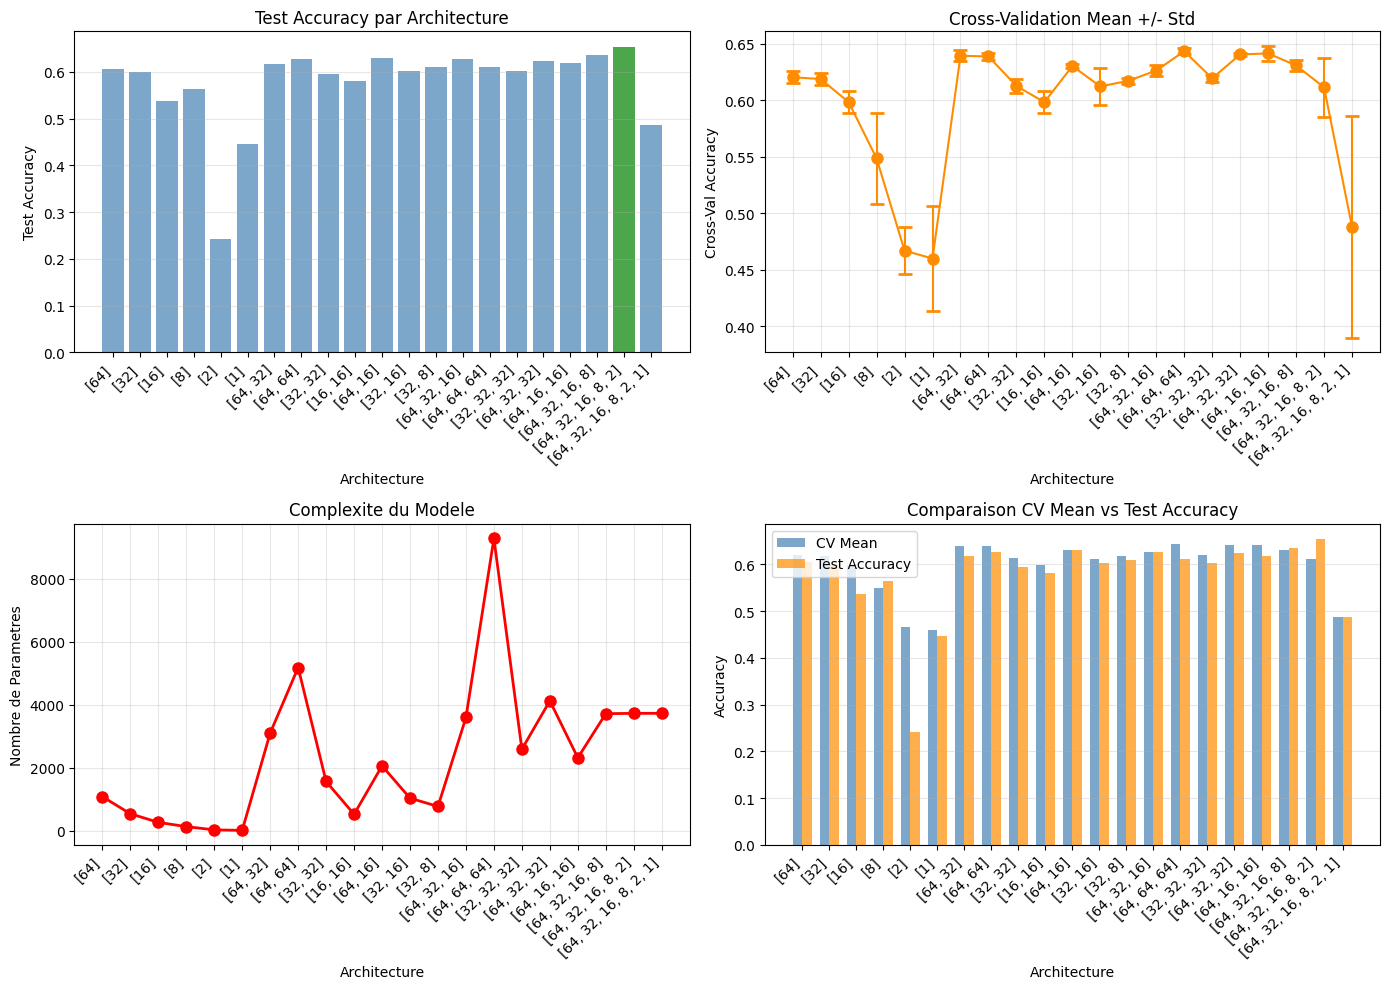


RESUME DE L'OPTIMISATION

Statistiques:
   Meilleure Test Accuracy: 0.6538
   Pire Test Accuracy: 0.2419
   Ecart: 0.4119

Architecture optimale (Index 19):
   Couches: [64, 32, 16, 8, 2]
   Test Accuracy: 0.6538
   CV Mean: 0.6115 +/- 0.0263
   Parametres: 3730
   Batch Size: 128



In [127]:
# ============= VISUALISATION DES RESULTATS =============
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

arch_labels = [str(eval(r)) for r in results['architecture']]
colors = ['green' if i == best_idx else 'steelblue' for i in range(len(results['test_accuracy']))]
ax1 = axes[0, 0]
ax1.bar(range(len(results['test_accuracy'])), results['test_accuracy'], color=colors, alpha=0.7)
ax1.set_xlabel('Architecture')
ax1.set_ylabel('Test Accuracy')
ax1.set_title('Test Accuracy par Architecture')
ax1.set_xticks(range(len(arch_labels)))
ax1.set_xticklabels(arch_labels, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[0, 1]
ax2.errorbar(range(len(results['cv_mean'])), results['cv_mean'], yerr=results['cv_std'], 
             fmt='o-', capsize=5, color='darkorange', capthick=2, markersize=8)
ax2.set_xlabel('Architecture')
ax2.set_ylabel('Cross-Val Accuracy')
ax2.set_title('Cross-Validation Mean +/- Std')
ax2.set_xticks(range(len(arch_labels)))
ax2.set_xticklabels(arch_labels, rotation=45, ha='right')
ax2.grid(alpha=0.3)

ax3 = axes[1, 0]
ax3.plot(range(len(results['total_params'])), results['total_params'], 'o-', 
         color='red', markersize=8, linewidth=2)
ax3.set_xlabel('Architecture')
ax3.set_ylabel('Nombre de Parametres')
ax3.set_title('Complexite du Modele')
ax3.set_xticks(range(len(arch_labels)))
ax3.set_xticklabels(arch_labels, rotation=45, ha='right')
ax3.grid(alpha=0.3)

ax4 = axes[1, 1]
x = range(len(results['architecture']))
width = 0.35
ax4.bar([i - width/2 for i in x], results['cv_mean'], width, label='CV Mean', alpha=0.7, color='steelblue')
ax4.bar([i + width/2 for i in x], results['test_accuracy'], width, label='Test Accuracy', alpha=0.7, color='darkorange')
ax4.set_xlabel('Architecture')
ax4.set_ylabel('Accuracy')
ax4.set_title('Comparaison CV Mean vs Test Accuracy')
ax4.set_xticks(range(len(arch_labels)))
ax4.set_xticklabels(arch_labels, rotation=45, ha='right')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============= RESUME =============
print("\n" + "="*80)
print("RESUME DE L'OPTIMISATION")
print("="*80)
print(f"\nStatistiques:")
print(f"   Meilleure Test Accuracy: {max(results['test_accuracy']):.4f}")
print(f"   Pire Test Accuracy: {min(results['test_accuracy']):.4f}")
print(f"   Ecart: {max(results['test_accuracy']) - min(results['test_accuracy']):.4f}")
print(f"\nArchitecture optimale (Index {best_idx}):")
print(f"   Couches: {results['architecture'][best_idx]}")
print(f"   Test Accuracy: {results['test_accuracy'][best_idx]:.4f}")
print(f"   CV Mean: {results['cv_mean'][best_idx]:.4f} +/- {results['cv_std'][best_idx]:.4f}")
print(f"   Parametres: {results['total_params'][best_idx]}")
print(f"   Batch Size: {results['batch_size'][best_idx]}")
print("="*80 + "\n")

In [128]:
# ============= ENTRAINEMENT DU MODELE FINAL =============
print("\n" + "="*80)
print("ENTRAINEMENT DU MODELE FINAL")
print("="*80)

best_arch = eval(results['architecture'][best_idx])
print(f"\nArchitecture selectionnee: {best_arch}")

best_hidden_layers = []
for units in best_arch:
    best_hidden_layers.append({
        'hidden_size': units,
        'activation': relu,
        'activation_prime': relu_prime
    })

best_arch_info = {
    'input_size': X_train.shape[1],
    'hidden_params': best_hidden_layers,
    'output_params': [{
        'output_size': 1,
        'activation': sigmoid,
        'activation_prime': sigmoid_prime
    }]
}

final_batch_size = calculate_dynamic_batch_size(
    X_train.shape[0], 
    memory_ratio=0.2,
    min_batch=16, 
    max_batch=128
)

print(f"\nParametres:")
print(f"   Batch Size: {final_batch_size}")
print(f"   Learning Rate: 0.01")
print(f"   Epochs: 15")
print(f"   Parametres totaux: {results['total_params'][best_idx]}")

print(f"\nEntrainement en cours...")
model_optimal = MLPWithBatches(best_arch_info, alpha=0.01, nb_iters=100)
model_optimal.fit_with_batches(X_train, Y_train, batch_size=final_batch_size, epochs=15)

print(f"\nEvaluations:")
Y_pred_train_final = model_optimal.predict(X_train)
Y_pred_val_final = model_optimal.predict(X_val)
Y_pred_test_final = model_optimal.predict(X_test)

train_acc_final = np.mean(Y_pred_train_final == Y_train)
val_acc_final = np.mean(Y_pred_val_final == Y_val)
test_acc_final = np.mean(Y_pred_test_final == Y_test)

print(f"   Train Accuracy: {train_acc_final:.4f}")
print(f"   Val Accuracy: {val_acc_final:.4f}")
print(f"   Test Accuracy: {test_acc_final:.4f}")

print("\nModele entraine.")
print("="*80 + "\n")


ENTRAINEMENT DU MODELE FINAL

Architecture selectionnee: [64, 32, 16, 8, 2]

Parametres:
   Batch Size: 128
   Learning Rate: 0.01
   Epochs: 15
   Parametres totaux: 3730

Entrainement en cours...
 Configuration:
   - Batch size: 128
   - Epochs: 15
   - Nombre d'exemples: 34450
   - Nombre de batches par epoch: 269
   - Exemples à traiter par epoch: 34432

Epoch 1/15, Cost: 1.6907
Epoch 2/15, Cost: 1.6918
Epoch 3/15, Cost: 1.6834
Epoch 4/15, Cost: 1.6664
Epoch 5/15, Cost: 1.6545
Epoch 6/15, Cost: 1.6314
Epoch 7/15, Cost: 1.6157
Epoch 8/15, Cost: 1.5893
Epoch 9/15, Cost: 1.5739
Epoch 10/15, Cost: 1.5465
Epoch 11/15, Cost: 1.5318
Epoch 12/15, Cost: 1.5157
Epoch 13/15, Cost: 1.5113
Epoch 14/15, Cost: 1.5037
Epoch 15/15, Cost: 1.4999

Evaluations:
   Train Accuracy: 0.6395
   Val Accuracy: 0.5172
   Test Accuracy: 0.5230

Modele entraine.

